# Direct Causal Cascade in the Stock Market  
### Reproducing Figures from Arnéodo, Muzy & Sornette (1998)

This notebook aims to reproduce, as closely as possible, the structure of Figures 1–3:

- **Figure 1:** log-price, centered log-volatility walk, shuffled version, and their autocorrelations.  
- **Figure 2:** log-volatility correlation vs log-lag for several scales.  
- **Figure 3:** mutual information cone across time and scale, for original and shuffled data.

Assumptions:
- Input data: CSV with columns `datetime, price` sampled at fixed interval (e.g. 5 minutes).
- We use a discrete wavelet transform with Haar wavelet to approximate the construction in the paper.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.style.use('seaborn-v0_8')
%matplotlib inline

from scipy.signal import fftconvolve

def covariance_fft(x):
    x = x - np.mean(x)
    c = fftconvolve(x, x[::-1], mode='full')
    c = c[c.size//2:]
    return c / c[0]


## 1. Load and preprocess data

We:
- Load intraday prices
- Compute log-prices
- Remove intraday seasonality from 1-step returns
- Reconstruct a deseasonalized log-price series (used for all subsequent analysis)


In [2]:


DATA_PATH = "SandP_log2min.dat"   # one value per row

# Try reading with header; if no header, fallback
try:
    df = pd.read_csv(DATA_PATH)
    if df.shape[1] == 1:
        df.columns = ['price']
except:
    df = pd.read_csv(DATA_PATH, header=None)
    df.columns = ['price']

df = df.dropna().reset_index(drop=True)

# Log-price
df['log_price'] = np.log(df['price'])

# Since there is no intraday pattern, we skip deseasonalization
df['log_price_deseason'] = df['log_price']

df.head()



,price,log_price,log_price_deseason
0,9.710267,2.273184,2.273184
1,9.710085,2.273165,2.273165
2,9.709599,2.273115,2.273115
3,9.709478,2.273103,2.273103
4,9.709296,2.273084,2.273084


## 2. Wavelet transform and centered log-volatility walk

We:
- Apply a discrete wavelet transform (Haar) to the deseasonalized log-price.
- Use detail coefficients to define scale-dependent fluctuations.
- Build local volatility and log-volatility at each scale.
- Construct the centered log-volatility walk at a chosen scale (~20 minutes).


In [3]:
import numpy as np
from scipy.signal import fftconvolve

# ---------------------------------------------------------
# Your Haar wavelet generator
# ---------------------------------------------------------
def haar_wavelet_scaled(a, dt):
    N = max(int(a / dt), 2)
    half = N // 2

    psi = np.zeros(N)
    psi[:half] = 1.0
    psi[half:] = -1.0

    return psi / a

# ---------------------------------------------------------
# Your FFT‑based Haar CWT
# ---------------------------------------------------------
def cwt_haar_fft(f, dt, scales):
    W = []
    for a in scales:
        psi = haar_wavelet_scaled(a, dt)
        conv = fftconvolve(f, psi[::-1], mode='same') * dt
        W.append(conv)
    return np.array(W)   # shape: (n_scales, n_time)

# ---------------------------------------------------------
# ADAPTED VERSION OF YOUR ORIGINAL CODE
# ---------------------------------------------------------


wavelet = "haar"   # unused now, but kept for consistency
max_level = 10

log_price = np.array(df['log_price_deseason'].values)
dt = 1.0  # or whatever your sampling interval is

# Replace DWT scales with CWT scales
scales = np.linspace(2,1024,50)
scales = [int(s) for s in scales]
print("scales:", scales)

# Compute Haar CWT (full-length coefficients)
detail_series = cwt_haar_fft(log_price, dt, scales)

print("\nHaar CWT detail series shape:", detail_series.shape)
print("(n_scales, n_time) =", detail_series.shape)




scales: [2, 22, 43, 64, 85, 106, 127, 148, 168, 189, 210, 231, 252, 273, 294, 314, 335, 356, 377, 398, 419, 440, 460, 481, 502, 523, 544, 565, 586, 606, 627, 648, 669, 690, 711, 732, 752, 773, 794, 815, 836, 857, 878, 898, 919, 940, 961, 982, 1003, 1024]

Haar CWT detail series shape: (50, 640533)
(n_scales, n_time) = (50, 640533)


## 3. Local volatility estimation

In [4]:
window = 50  # window for local volatility

vol_series = []
for s_idx in range(len(scales)):
    d = detail_series[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series.append(vol)

vol_series = np.array(vol_series)
log_vol_series = np.log(vol_series + 1e-12)

# Choose a scale index for ~20 min (adjust if your base step != 5 min)
scale_idx_20m = 5  # e.g. 2 * base step
w_a = log_vol_series[scale_idx_20m]
w_a_centered = w_a - np.mean(w_a)
v_a = np.cumsum(w_a_centered)

len(v_a)


640533

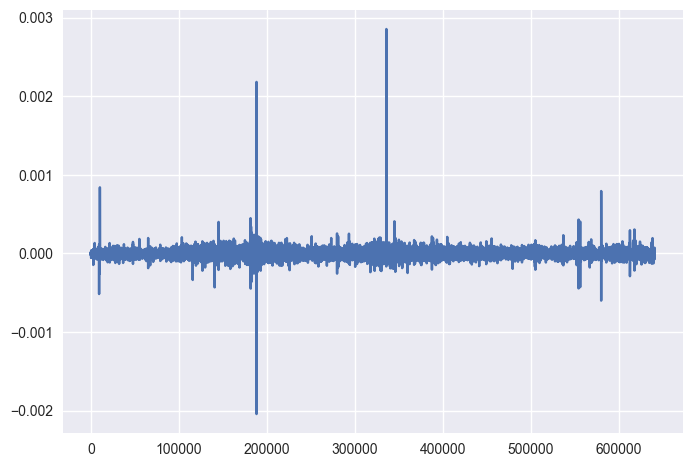

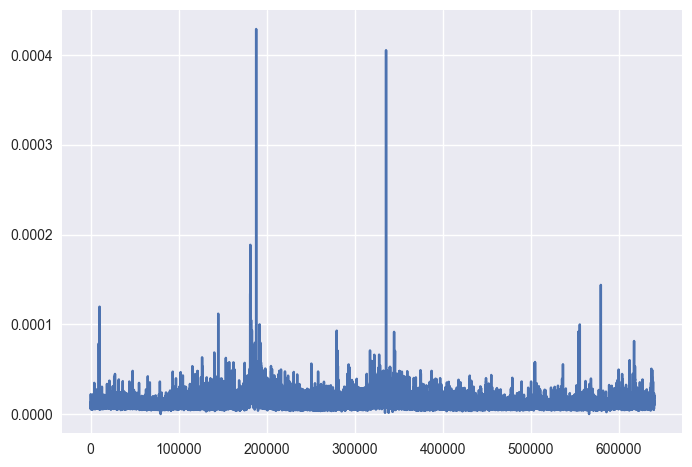

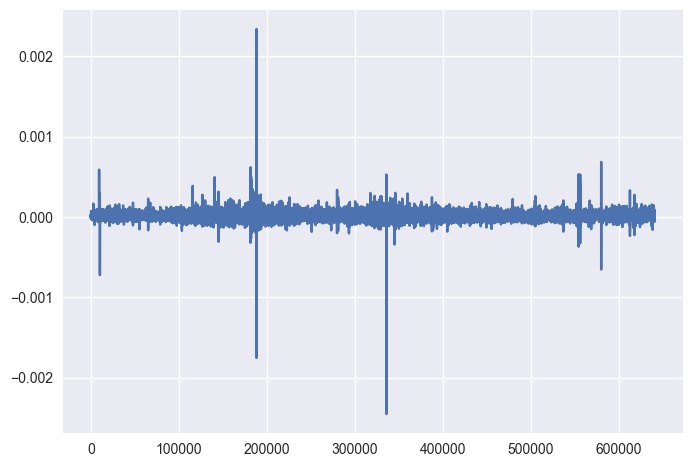

In [5]:
ind = 0

plt.plot(detail_series[ind][100:])
plt.show()
plt.plot(vol_series[ind][100:])
plt.show()
plt.plot(vol_series[ind][100:]-detail_series[ind][100:])
plt.show()

## 3. Figure 1: log-price, centered log-volatility walk, shuffled version

We now build the three time series:
- (a) log-price
- (b) centered log-volatility walk
- (c) same after shuffling the increments of log-price (as in the paper).


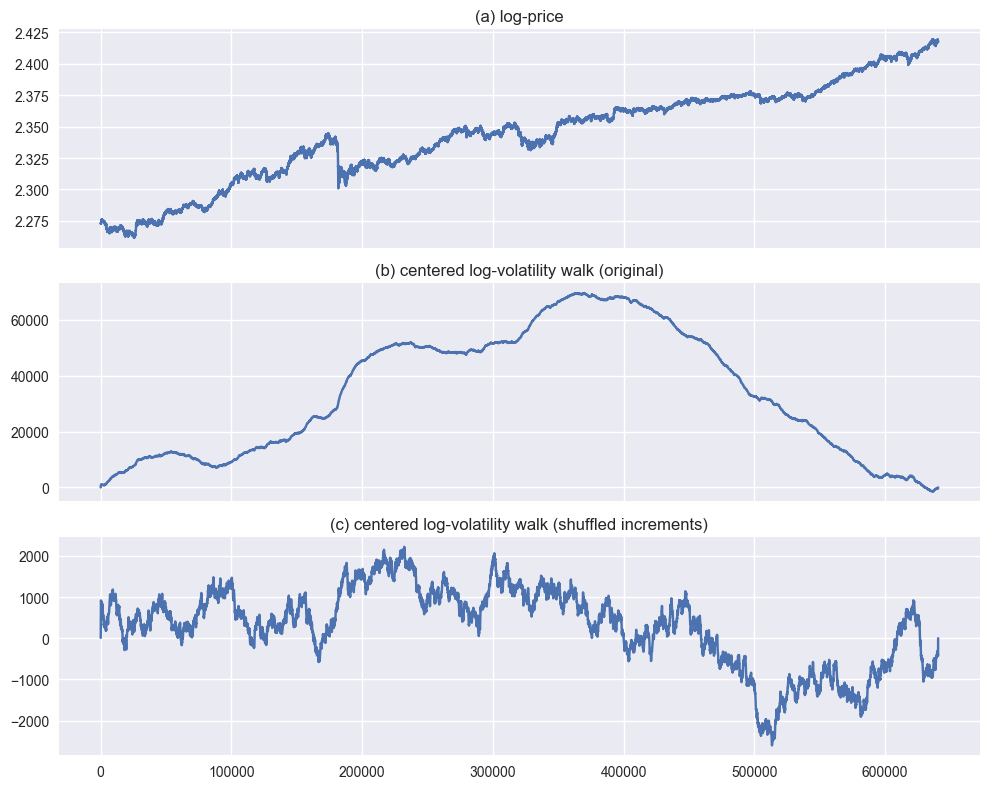

In [6]:
# (a) log-price
t = np.arange(len(df))
logP = df['log_price_deseason'].values

# (c) shuffled increments version
increments = np.diff(logP)
shuffled_increments = np.random.permutation(increments)
logP_shuffled = np.concatenate([[logP[0]], logP[0] + np.cumsum(shuffled_increments)])

# Recompute wavelet-based log-volatility walk for shuffled series
detail_series_sh = cwt_haar_fft(logP_shuffled, dt, scales)


vol_series_sh = []
for s_idx in range(len(scales)):
    d = detail_series_sh[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series_sh.append(vol)
vol_series_sh = np.array(vol_series_sh)
log_vol_series_sh = np.log(vol_series_sh + 1e-12)

w_a_sh = log_vol_series_sh[scale_idx_20m]
w_a_sh_centered = w_a_sh - np.mean(w_a_sh)
v_a_sh = np.cumsum(w_a_sh_centered)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t, logP)
axes[0].set_title('(a) log-price')

axes[1].plot(t, v_a)
axes[1].set_title('(b) centered log-volatility walk (original)')

axes[2].plot(t, v_a_sh)
axes[2].set_title('(c) centered log-volatility walk (shuffled increments)')

plt.tight_layout()
plt.show()


## 4. Autocorrelation of returns vs log-volatility

### Figure 1′: Autocorrelations (returns and log-volatility)

We compute:
- (a′) autocorrelation of 1-step returns
- (b′) autocorrelation of log-volatility at scale ~20 min
- (c′) same for shuffled series


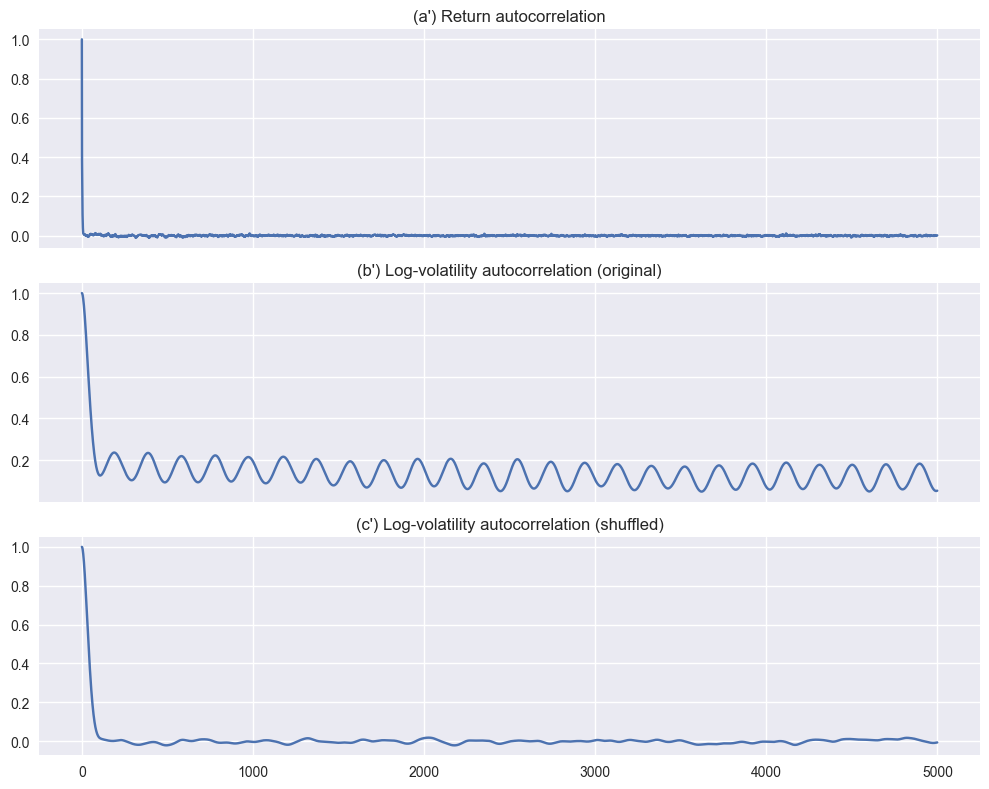

In [7]:
from scipy.signal import fftconvolve

def covariance_fft(x):
    x = x - np.mean(x)
    c = fftconvolve(x, x[::-1], mode='full')
    c = c[c.size//2:]
    return c / c[0]

def corr_function(x, max_lag):
    """
    Normalized autocorrelation function C(Δt) for a 1D series x,
    for lags 0..max_lag.
    """
    x = np.asarray(x, float)
    n = len(x)

    # raw autocovariance via FFT convolution
    c = covariance_fft(x)

    # unbiased normalization by number of overlapping points
    norm = np.arange(n, 0, -1)
    c = c / norm

    # normalize to get correlation function: C(0) = 1
    c = c / c[0]

    return c[:max_lag + 1]

max_lag = 5000

# (a′) return autocorrelation
ret = np.diff(df['log_price_deseason'].values)
ret_ac = covariance_fft(ret)

# (b′) log-volatility autocorrelation (original)
w = w_a
w_ac = covariance_fft(w)

# (c′) log-volatility autocorrelation (shuffled)
w_sh = w_a_sh
w_sh_ac = covariance_fft(w_sh)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(ret_ac[:max_lag])
axes[0].set_title("(a') Return autocorrelation")

axes[1].plot(w_ac[:max_lag])
axes[1].set_title("(b') Log-volatility autocorrelation (original)")

axes[2].plot(w_sh_ac[:max_lag])
axes[2].set_title("(c') Log-volatility autocorrelation (shuffled)")

plt.tight_layout()
plt.show()


## 4. Figure 2: Log-volatility correlation vs log-lag for several scales(TODO - wrong figure)

We:
- Choose several scales (e.g. small, medium, large)
- Compute autocorrelation of log-volatility at each scale
- Plot correlation vs \\(\\ln \\Delta t\\) and show the collapse.


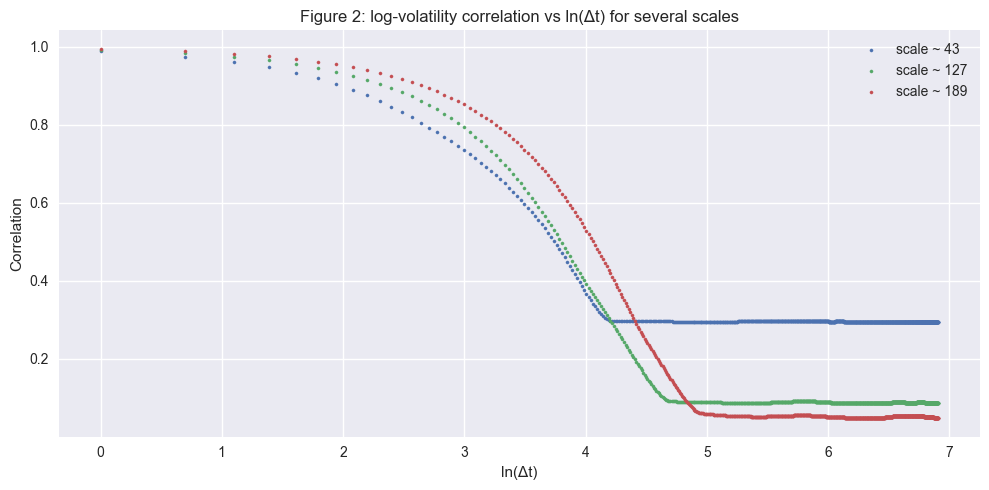

In [8]:
# Choose a few scale indices (adjust depending on your sampling)
scale_indices = [2, 6, 9]  # example: smaller, medium, larger scales
labels = [f'scale ~ {scales[i]}' for i in scale_indices]

max_lag_fig2 = 1000
lags = np.arange(1, max_lag_fig2+1)

plt.figure(figsize=(10, 5))
for idx, lab in zip(scale_indices, labels):
    w_s = log_vol_series[idx]          # this is ω_a(t)
    C = corr_function(w_s,max_lag_fig2)
    # skip lag 0, plot Δt = 1..max_lag
    plt.scatter(np.log(lags), C[1:], s=5, label=lab)

plt.xlabel('ln(Δt)')
plt.ylabel('Correlation')
plt.title('Figure 2: log-volatility correlation vs ln(Δt) for several scales')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Figure 3: Mutual information cone across time and scale (TODO - doesn't seem to show what was shown in the paper)

We compute the mutual information between log-volatility at different scales and times, using the Gaussian approximation:

\

\[
I = -\\frac{1}{2} \\log(1 - \\rho^2),
\\]



where \\(\\rho\\) is the Pearson correlation.


4050
Progress: 1/4050
Progress: 11/4050
Progress: 21/4050
Progress: 31/4050
Progress: 41/4050
Progress: 51/4050
Progress: 61/4050
Progress: 71/4050
Progress: 81/4050
Progress: 91/4050
Progress: 101/4050
Progress: 111/4050
Progress: 121/4050
Progress: 131/4050
Progress: 141/4050
Progress: 151/4050
Progress: 161/4050
Progress: 171/4050
Progress: 181/4050
Progress: 191/4050
Progress: 201/4050
Progress: 211/4050
Progress: 221/4050
Progress: 231/4050
Progress: 241/4050
Progress: 251/4050
Progress: 261/4050
Progress: 271/4050
Progress: 281/4050
Progress: 291/4050
Progress: 301/4050
Progress: 311/4050
Progress: 321/4050
Progress: 331/4050
Progress: 341/4050
Progress: 351/4050
Progress: 361/4050
Progress: 371/4050
Progress: 381/4050
Progress: 391/4050
Progress: 401/4050
Progress: 411/4050
Progress: 421/4050
Progress: 431/4050
Progress: 441/4050
Progress: 451/4050
Progress: 461/4050
Progress: 471/4050
Progress: 481/4050
Progress: 491/4050
Progress: 501/4050
Progress: 511/4050
Progress: 521/4050

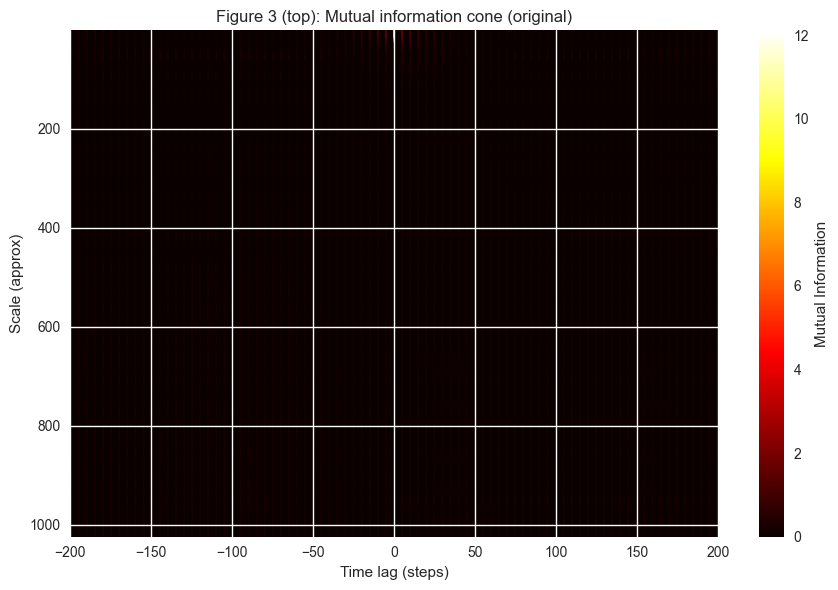

In [9]:
import numpy as np
from sklearn.feature_selection import mutual_info_regression
import multiprocess as mp

# -----------------------------
# 1. Precompute centered series
# -----------------------------
max_time_lag = 200
ref_idx = 0  # smallest scale as reference

w_a_centered_list = [log_vol - np.mean(log_vol) for log_vol in log_vol_series]
w_ref = w_a_centered_list[ref_idx]

I_map = np.zeros((len(scales), 2*max_time_lag+1))

# -----------------------------
# 2. Worker function
# -----------------------------
def compute_I(args):
    """
    args = (s_idx, dt, w_a_centered_list, w_ref)
    Everything is passed explicitly so workers don't rely on notebook globals.
    """
    import numpy as np
    from sklearn.feature_selection import mutual_info_regression

    s_idx, dt, w_list, w_ref_local = args

    w_other = w_list[s_idx]

    # Align time series depending on lag
    if dt >= 0:
        x = w_other[:-dt or None]
        y = w_ref_local[dt:]
    else:
        x = w_other[-dt:]
        y = w_ref_local[:dt or None]

    # Too short → skip
    if len(x) < 10:
        return 0.0

    # Compute MI
    I = mutual_info_regression(x.reshape(-1,1), y, n_jobs=1)
    return float(I[0])

# -----------------------------
# 3. Build task list
# -----------------------------
tasks = [
    (s_idx, dt, w_a_centered_list, w_ref)
    for s_idx in range(len(scales))
    for dt in range(-max_time_lag, max_time_lag+1,5)
]
print(len(tasks))
# -----------------------------
# 4. Run multiprocessing
# -----------------------------
results = []
with mp.Pool(mp.cpu_count()) as pool:
    for i, result in enumerate(pool.imap(compute_I, tasks)):
        results.append(result)
        if i%10==0:
            print(f"Progress: {i + 1}/{len(tasks)}")

# -----------------------------
# 5. Fill I_map
# -----------------------------
for i, (s_idx, dt, _, _) in enumerate(tasks):
    I_map[s_idx, dt + max_time_lag] = results[i]

    

plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_map, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()



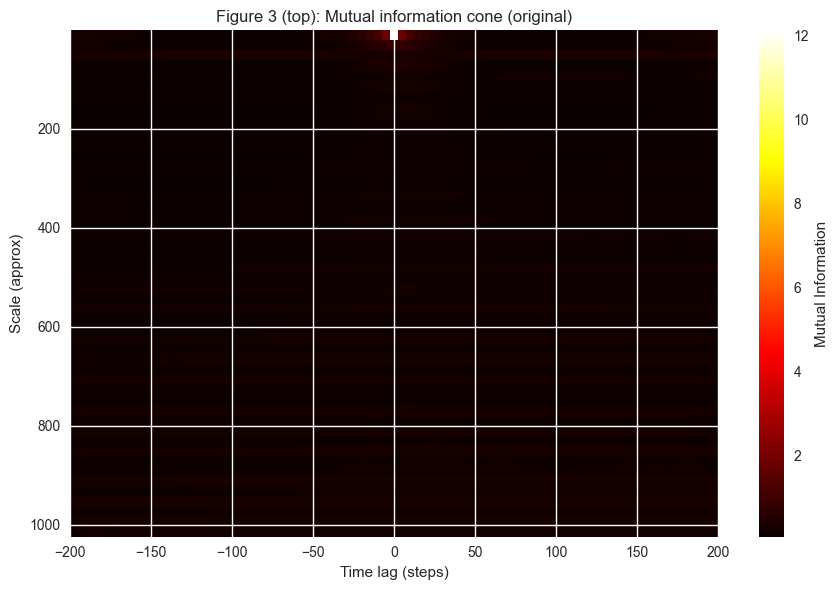

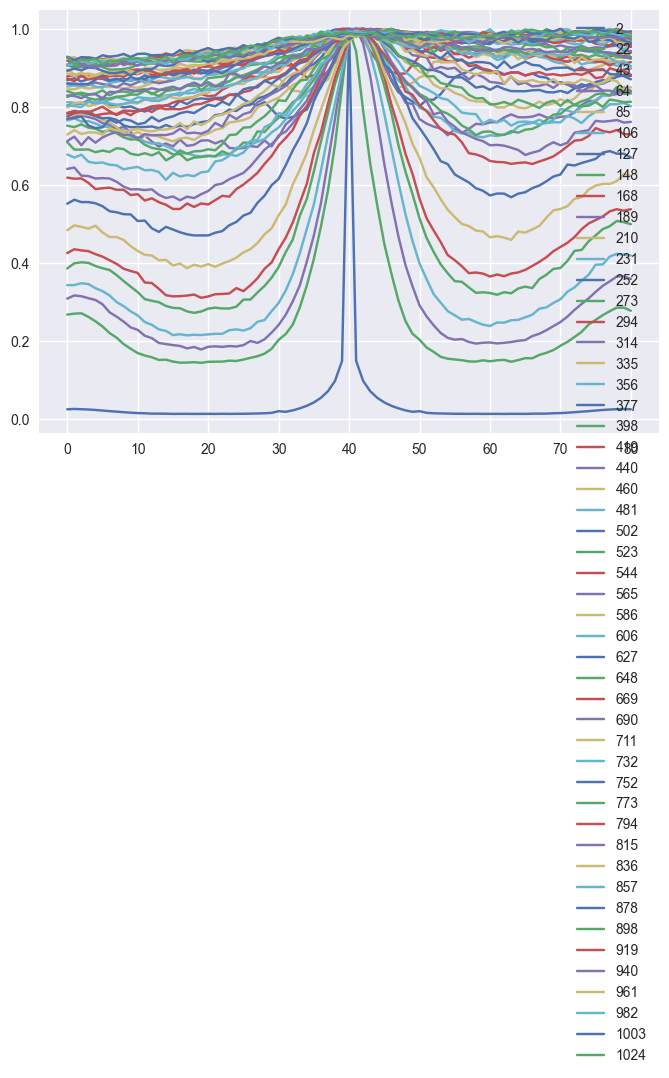

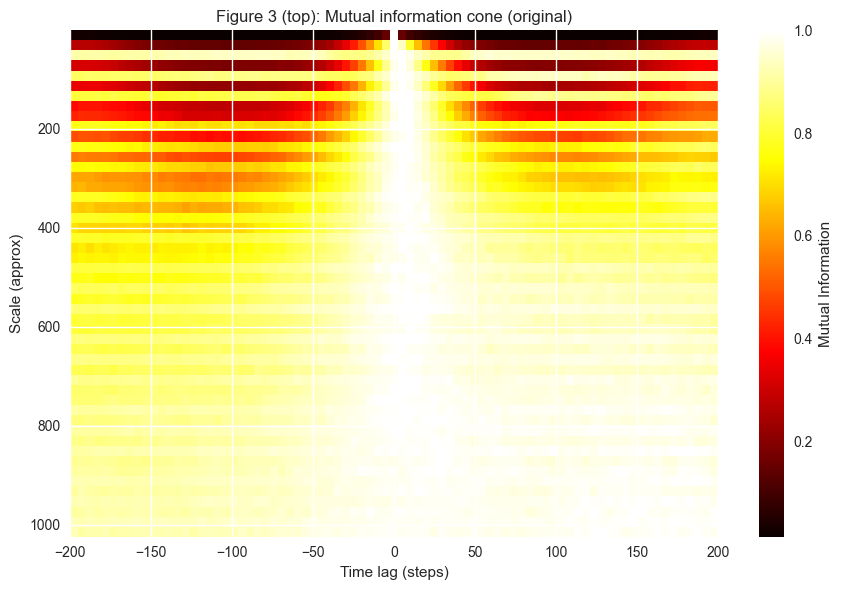

In [20]:
I_map_without_gaps = []
for row in I_map:
    I_map_without_gaps.append(row[row>0])

plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_map_without_gaps, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()


I_normalized = []
for i,I in enumerate(I_map):
    I_normalized.append(I[I>0]/np.max(I[I>0]))
    plt.plot(I_normalized[i],label=scales[i])

plt.legend()
plt.show()
plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_normalized, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()

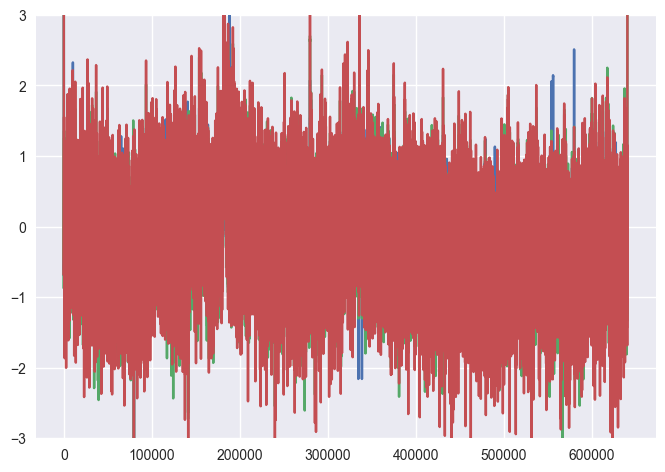

In [35]:
plt.plot(w_a_centered_list[0])
plt.plot(w_a_centered_list[1])
# plt.plot(w_a_centered_list[2])
plt.plot(w_a_centered_list[3])
# plt.plot(w_a_centered_list[4])
plt.ylim((-3,3))

plt.show()

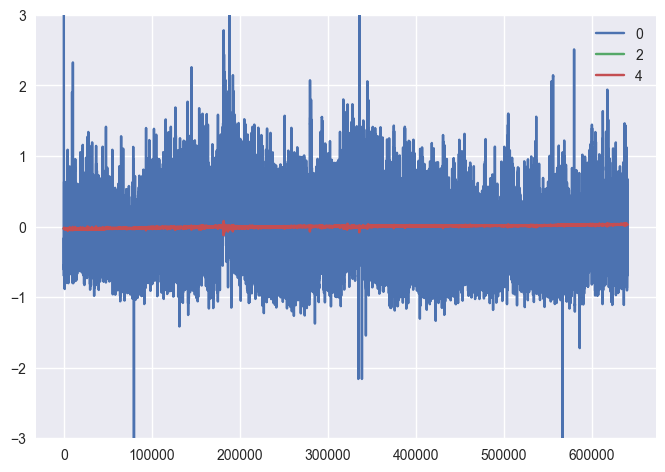

In [38]:
plt.plot(w_a_centered_list[0],label=0)
# plt.plot(w_a_centered_list[1])
plt.plot(w_a_centered_list[2][100:-100],label=2)
# plt.plot(w_a_centered_list[3])
plt.plot(w_a_centered_list[4][100:-100],label=4)
plt.ylim((-3,3))
plt.legend()
plt.show()

In [ ]:
I_map_slow = np.load("I_map_paper.npy")

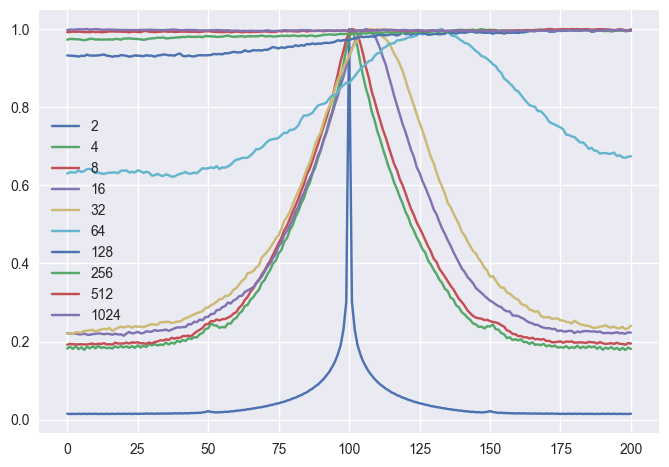

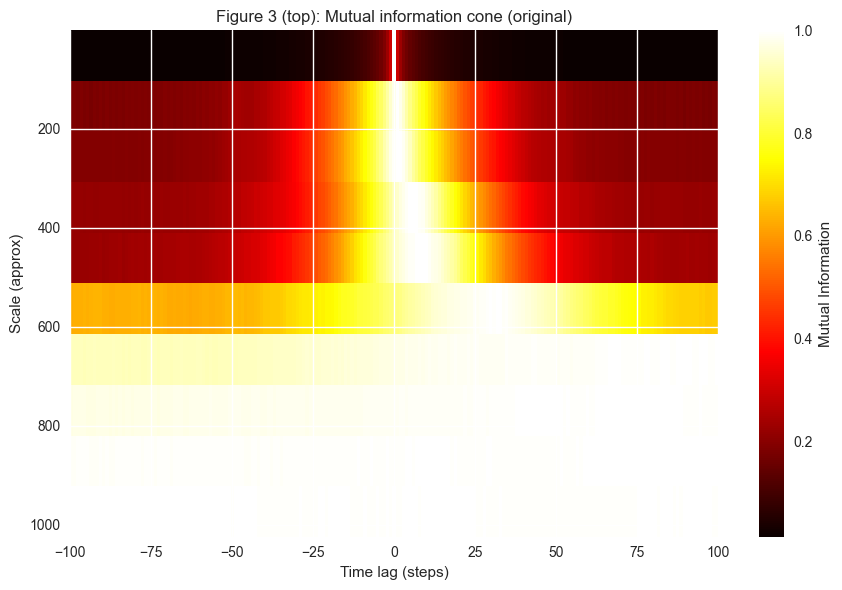

In [ ]:
I_normalized_slow = []
for i,I in enumerate(I_map_slow):
    I_normalized_slow.append(I/np.max(I))
    plt.plot(I_normalized_slow[i],label=scales[i])

plt.legend()
plt.show()
plt.figure(figsize=(9, 6))
extent = [-100, 100, scales[-1], scales[0]]
plt.imshow(I_normalized_slow, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()

### Shuffled control for Figure 3 (TODO)

We repeat the mutual information computation for the shuffled series, which should destroy the cascade structure and yield a noisy, structureless map.


In [ ]:
logP_shuffled2 = logP_shuffled  # from earlier
detail_series_sh2 = cwt_haar_fft(logP_shuffled, dt, scales)

# detail_series_sh2 = []
# for level in range(1, max_level+1):
#     cD = coeffs_sh2[-level]
#     up = upsample_to_length(cD, level, len(logP_shuffled2))
#     detail_series_sh2.append(up)
detail_series_sh2 = np.array(detail_series_sh2)

vol_series_sh2 = []
for s_idx in range(len(scales)):
    d = detail_series_sh2[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series_sh2.append(vol)
vol_series_sh2 = np.array(vol_series_sh2)
log_vol_series_sh2 = np.log(vol_series_sh2 + 1e-12)

w_ref_sh = log_vol_series_sh2[ref_idx]
I_map_sh = np.zeros((len(scales), 2*max_time_lag+1))

for s_idx in range(len(scales)):
    w_other = log_vol_series_sh2[s_idx]
    for dt in range(-max_time_lag, max_time_lag+1):
        if dt >= 0:
            x = w_other[:-dt or None]
            y = w_ref_sh[dt:]
        else:
            x = w_other[-dt:]
            y = w_ref_sh[:dt or None]
        if len(x) < 10:
            I = 0
        else:
            I = gaussian_MI(x, y)
        I_map_sh[s_idx, dt + max_time_lag] = I

plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_map_sh, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (bottom): Mutual information cone (shuffled)')
plt.tight_layout()
plt.show()
